### Whole-brain network model: forced oscillations

We construct a whole-brain network model and force it to oscillate, starting from a state of constant high or low activity.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

datadir = os.path.join("examples", "data")

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions
from neurolib.utils.plot_oc import plot_oc_singlenode, plot_oc_network

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

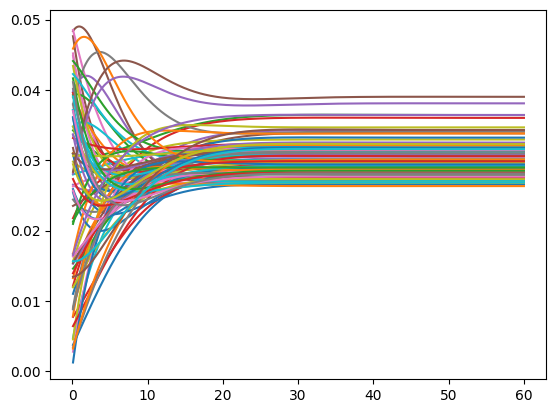

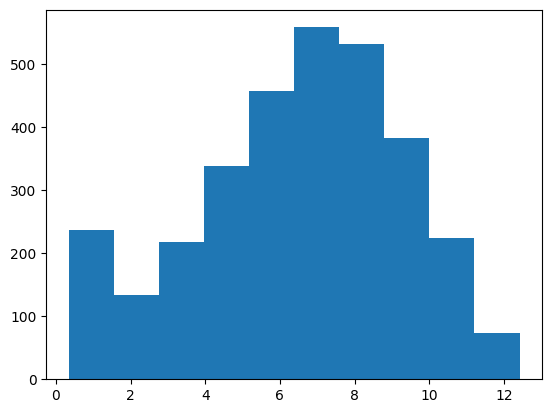

In [2]:
from neurolib.utils.loadData import Dataset
ds = Dataset("hcp")  #alternatively, you can use Dataset("gw")

model = WCModel(Cmat = ds.Cmat, Dmat = ds.Dmat)
duration = 60.
model.params['duration'] = duration
model.params['K_gl'] = 1.0

N = model.params.N
dt = model.params.dt

# set static external input to find a state of constant high activity
model.params['exc_ext_baseline'] = 0.4
model.params['inh_ext_baseline'] = 0.

model.run()

plt.plot(model.t, model.exc.T)
plt.show()

dentries = []
for n in range(N):
    for k in range(n+1, N):
        dentries.append(model.params.lengthMat[n,k]/ model.params.signalV)

plt.hist(dentries)
plt.show()

# for up state, chose e_ext = 3, i_ext = 0
for n in range(N):
    model.params["exc_init"][n,-1] = model.exc[n, -1]
    model.params["inh_init"][n,-1] = model.inh[n, -1]

model.run()

In [ ]:
# set target oscillation period; as the inter-areal delay is centered around 7, we chose this value as the target period, such that network effects can be leveraged by the optimal control
target_period = 7.

# set cost matrix and control matrix
cost_mat = np.zeros( (model.params.N, len(model.output_vars)) )
cost_mat[:,0] = 1. # only measure in exc channel in all nodes

control_mat = np.zeros( (model.params.N, len(model.input_vars)) )
control_mat[:,0] = 1. # only enable inputs to exc channel in all nodes

# set control interval to [10, 90]
control_interval = [50, 550]

control_init = np.zeros((N, 2, int(duration/model.params.dt)+1))
for n in range(N):
    control_init[n,0,control_interval[0]:control_interval[1]] = -0.5*(1. + np.sin(np.linspace(-0.5*np.pi, 7.5*np.pi, control_interval[1] - control_interval[0])))

We first compute the control using the enery cost. This will yield control signals that target all network nodes at low input strength.

In [ ]:
# initialize control signals
control_e, control_ds, control_ts = None, None, None

In [ ]:
# read control signals from file (optimization is time-consuming)
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'rb') as handle:
    [control_e, control_ds, control_ts] = pickle.load(handle)

In [ ]:
model_controlled_e = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_e.weights["w_p"] = 0.
model_controlled_e.weights["w_2"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"

model_controlled_e.channelwise_optimization = False
model_controlled_e.step =  2*1e1
for wf in [1e9, 9*1e7, 7*1e7, 4*1e7]:
    model_controlled_e.weights["w_f_osc"] = wf
    model_controlled_e.optimize(2)

model_controlled_e.weights["w_f_osc"] = 0.
model_controlled_e.weights["w_f_sync"] = 1e8
model_controlled_e.step = 1e2
model_controlled_e.optimize(1)

In [ ]:
limweight = 4.9 * 1e5

while model_controlled_e.weights["w_f_sync"] > limweight:
    total_cost = model_controlled_e.compute_total_cost()
    sp_cost = cost_functions.control_strength_cost(model_controlled_e.control, model_controlled_e.weights, dt)
    f_cost = np.sum(cost_functions.fourier_cost_sync(model_controlled_e.get_xs(), dt, target_period, cost_mat, control_interval))
    weight = - sp_cost/f_cost + 1e-6
    print("weight = ", weight)

    model_controlled_e.step =  1e1
    #model_controlled_e.channelwise_optimization = True
    model_controlled_e.weights["w_f_sync"] = max(weight, limweight)
    model_controlled_e.optimize(1)

    control_e = model_controlled_e.control

In [ ]:
# read from saved data, if results have been computed previously
if type(control_e) != type(None):
    model_controlled_e.control = control_e.copy()
    model_controlled_e.update_input()

# re-run this code to run another 100 iterations
model_controlled_e.channelwise_optimization = False
model_controlled_e.optimize(100)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_e.channelwise_optimization = True
model_controlled_e.optimize(100)

control_e = model_controlled_e.control

In [ ]:
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'wb') as handle:
    pickle.dump([control_e, control_ds, control_ts], handle)

We then compute the control using the directional sparsity cost. This will yield control signals that target a subset of network nodes.

In [ ]:
model_controlled_ds = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_ds.weights["w_p"] = 0.
model_controlled_ds.weights["w_1D"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"

model_controlled_ds.channelwise_optimization = True

# reduce weight iteratively for initialization
model_controlled_ds.step =  1e6
for wf in [3. * 1e7, 1. * 1e7, 5. * 1e6, 3. * 1e6]:
    model_controlled_ds.weights["w_f_sync"] = wf
    model_controlled_ds.optimize(3)

control_ds = model_controlled_ds.control.copy()

In [ ]:
limweight = 2.95 * 1e5
model_controlled_ds.weights["w_f_sync"] = limweight+1

while model_controlled_ds.weights["w_f_sync"] > limweight:
    sp_cost = cost_functions.control_strength_cost(model_controlled_ds.control, model_controlled_ds.weights, dt)
    f_cost = np.sum(cost_functions.fourier_cost_sync(model_controlled_ds.get_xs(), dt, target_period, cost_mat, control_interval))
    weight = - sp_cost/f_cost + 1e-6
    print("weight = ", weight)

    model_controlled_ds.weights["w_f_sync"] = weight
    model_controlled_ds.optimize(2)

    control_ds = model_controlled_ds.control

In [ ]:
# read from saved data, if results have been computed previously
if type(control_ds) != type(None):
    model_controlled_ds.control = control_ds.copy()
    model_controlled_ds.update_input()

# re-run this code to run another 100 iterations
model_controlled_ds.channelwise_optimization = False
model_controlled_ds.optimize(100)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_ds.channelwise_optimization = True
model_controlled_ds.optimize(100)

control_ds = model_controlled_ds.control

In [ ]:
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'wb') as handle:
    pickle.dump([control_e, control_ds, control_ts], handle)

We then compute the control using the temporal sparsity cost. This will yield control signals that are nonzero only during short time spans during the control time interval

In [ ]:
model_controlled_ts = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_ts.weights["w_p"] = 0.
model_controlled_ts.weights["w_1T"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"
model_controlled_ts.control = control_init.copy()
model_controlled_ts.update_input()
#model_controlled_ts.maximum_control_strength = 5.

# we iteratively adjust the weight
model_controlled_ts.weights["w_f_sync"] = 1.5 * 1e6
model_controlled_ts.optimize(2)

control_ts = model_controlled_ts.control

In [ ]:
limweight = 0.

while model_controlled_ts.weights["w_f_sync"] > limweight:
    total_cost = model_controlled_ts.compute_total_cost()
    sp_cost = cost_functions.control_strength_cost(model_controlled_ts.control, model_controlled_ts.weights, dt)
    f_cost = np.sum(cost_functions.fourier_cost_sync(model_controlled_ts.get_xs(), dt, target_period, cost_mat, control_interval))
    weight = - sp_cost/f_cost + 1e-6
    print("weight = ", weight)

    model_controlled_ts.step =  1e1
    model_controlled_ts.weights["w_f_sync"] = max(weight, limweight)
    #model_controlled_ts.channelwise_optimization = False
    if model_controlled_ts.channelwise_optimization is True:
        model_controlled_ts.channelwise_optimization = False
    else:
        model_controlled_ts.channelwise_optimization = True
    model_controlled_ts.optimize(4)

    control_ts = model_controlled_ts.control

In [ ]:
# read from saved data, if results have been computed previously
if type(control_ts) != type(None):
    model_controlled_ts.control = control_ts.copy()
    model_controlled_ts.update_input()

# re-run this code to run another 20 iterations
model_controlled_ts.channelwise_optimization = False
model_controlled_ts.optimize(10)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_ts.channelwise_optimization = True
model_controlled_ts.optimize(10)

control_ts = model_controlled_ts.control

In [ ]:
with open(os.path.join(datadir, 'data_osc_wb.pickle'), 'wb') as handle:
    pickle.dump([control_e, control_ds, control_ts], handle)

In [ ]:
# if the data is read from file, the controlled models have to be initialized and the control signals have to be set
model_controlled_e = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_ds = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled_ts = oc_wc.OcWc(model, target_period, print_array=np.arange(0,1001,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)

if type(control_e) != type(None):
    model_controlled_e.control = control_e.copy()
    model_controlled_e.update_input()

if type(control_ds) != type(None):
    model_controlled_ds.control = control_ds.copy()
    model_controlled_ds.update_input()

if type(control_ts) != type(None):
    model_controlled_ts.control = control_ts.copy()
    model_controlled_ts.update_input()

Plot all three cases for comparison

In [ ]:
# compute the percentage of time during which the control is nonzero
def get_nonzero_percent(control, lim=1e-3):
    nonzero = []
    for n in range(N):
        ind_nonzero = 0
        for t in np.arange(control_interval[0], control_interval[1]+1, 1):
            if np.abs(control[n,0,t]) > lim:
                ind_nonzero += 1

        nonzero.append(ind_nonzero/(control_interval[1] - control_interval[0]-1))
    return nonzero

time = np.arange(0, duration+dt, dt)
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(2,3, figsize=(16,6), sharex=True)

model_controlled_e.optimize(0)
state = model_controlled_e.get_xs()
control_e = model_controlled_e.control.copy()

n_active = 0
for n in range(N):
    ax[0,0].plot(time, state[n,0,:], linewidth=1)
    ax[1,0].plot(time, control_e[n,0,:], linewidth=1)
    if np.sum(np.abs(control_e[n,0,:]**2)) > 1e-3:
        n_active += 1

ax[1,0].text(0.53, 0.95, "Active nodes: " + str(n_active), horizontalalignment='left', verticalalignment='center', transform=ax[1,0].transAxes)
ax[1,0].text(0.53, 0.85, "Active time: {:.0f}%".format(100.*np.mean(get_nonzero_percent(control_e))), horizontalalignment='left', verticalalignment='center', transform=ax[1,0].transAxes)

model_controlled_ds.optimize(0)
state = model_controlled_ds.get_xs()
control_ds = model_controlled_ds.control.copy()

n_active = 0
for n in range(N):
    ax[0,1].plot(time, state[n,0,:], linewidth=1)
    ax[1,1].plot(time, control_ds[n,0,:], linewidth=1)
    if np.sum(np.abs(control_ds[n,0,:]**2)) > 1e-3:
        n_active += 1
ax[1,1].text(0.53, 0.95, "Active nodes: " + str(n_active), horizontalalignment='left', verticalalignment='center', transform=ax[1,1].transAxes)
ax[1,1].text(0.53, 0.85, "Active time: {:.0f}%".format(100.*np.mean(get_nonzero_percent(control_ds))), horizontalalignment='left', verticalalignment='center', transform=ax[1,1].transAxes)

model_controlled_ts.optimize(0)
state = model_controlled_ts.get_xs()
control_ts = model_controlled_ts.control.copy()

n_active = 0
for n in range(N):
    ax[0,2].plot(time, state[n,0,:], linewidth=1)
    ax[1,2].plot(time, control_ts[n,0,:], linewidth=1)
    if np.sum(np.abs(control_ts[n,0,:]**2)) > 1e-3:
        n_active += 1
ax[1,2].text(0.53, 0.95, "Active nodes: " + str(n_active), horizontalalignment='left', verticalalignment='center', transform=ax[1,2].transAxes)
ax[1,2].text(0.53, 0.85, "Active time: {:.0f}%".format(100.*np.mean(get_nonzero_percent(control_ts))), horizontalalignment='left', verticalalignment='center', transform=ax[1,2].transAxes)

ax[0,0].set_xlim(0, duration)

for i in range(2):
    for j in range(3):
        ax[i,j].axvspan(0, dt*control_interval[0], -10, 10, facecolor='gray', alpha=0.4)
        ax[i,j].axvspan(dt*control_interval[1], duration+1, -10, 10, facecolor='gray', alpha=0.4)

ax[0,0].set_ylabel("Activity")
ax[1,0].set_ylabel("Control")

for i in range(3):
    ax[0,i].set_ylim(0, 0.5)
ax[1,0].set_ylim(-2.5, 4)
ax[1,1].set_ylim(-7.5, 9.5)
ax[1,2].set_ylim(-36, 42)

ax[1,0].set_xlabel("Time")
ax[1,1].set_xlabel("Time")
ax[1,2].set_xlabel("Time")

ax[0,0].set_title("Energy cost")
ax[0,1].set_title("Directional sparsity cost")
ax[0,2].set_title("Temporal sparsity cost")

fig.align_labels()
plt.subplots_adjust(wspace=0.14, hspace=0.1)
plt.savefig("WB_osc.pdf", bbox_inches='tight')

plt.show()

### Transitions between stationary state and oscillations in whole-brain network model

We consider a point in state space, at which a stable stationary state coexsits with a stable oscillatory state. We induce transitions between these states using the cross-correlation and the variance cost.

In [7]:
data = dict()

data["init"] = [None, None]
data["control_e"] = [[None, None], [None, None]]
data["state_e"] = [[None, None], [None, None]]
data["control_ds"] = [[None, None], [None, None]]
data["state_ds"] = [[None, None], [None, None]]
data["control_ts"] = [[None, None], [None, None]]
data["state_ts"] = [[None, None], [None, None]]

# compute the oscillation period of a state trajectory
def getperiod(data, dt):
    maxfreq = []
    for i_d,d in enumerate(data):
        ps = np.abs(np.fft.fft(d))
        ps_ = ps[:int(len(ps)/2)] / (len(ps)/2)
        ps_[0] = 0.
        fr = np.linspace(0,1./(2.*dt),len(ps_))
        maxfreqind = np.where(ps_ == max(ps_[1:]))
        maxfreq.append((1./fr[maxfreqind])[0])

    return np.mean(maxfreq)

31


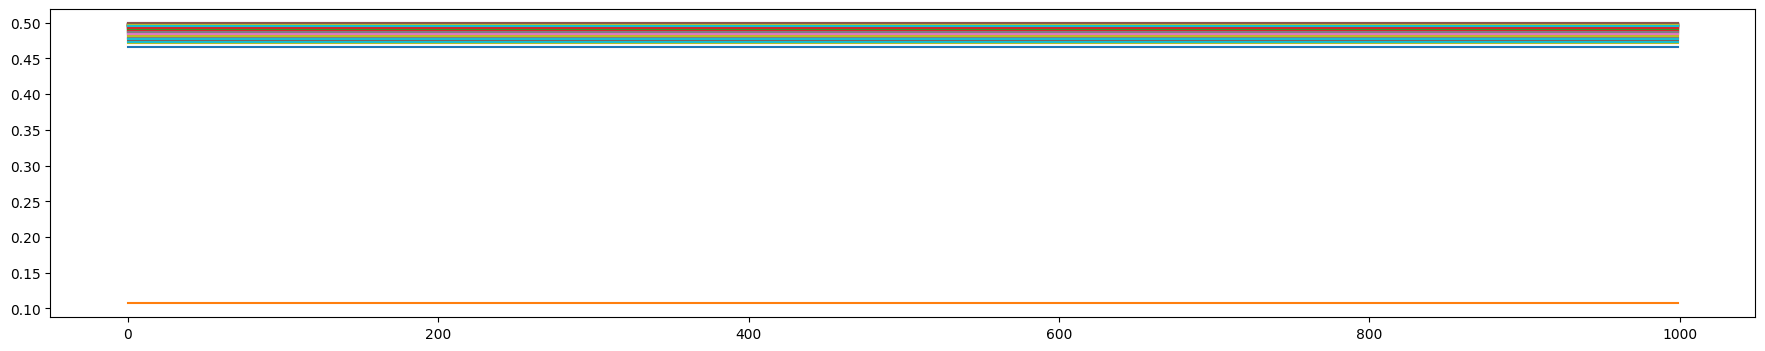

period =  9.98
period =  12.475
period =  12.475
period =  11.08888888888889
period =  9.98
period =  9.98
period =  9.98
period =  11.08888888888889
period =  9.98
period =  9.98
period =  9.98


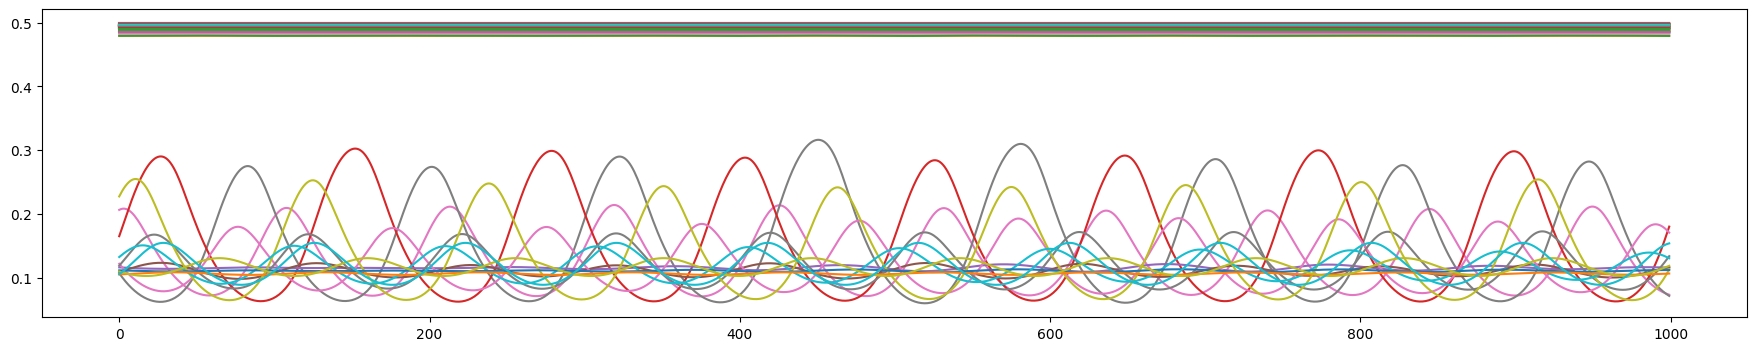

In [8]:
from neurolib.utils.loadData import Dataset
ds = Dataset("hcp")  #alternatively, you can use Dataset("gw")

model = WCModel(Cmat = ds.Cmat, Dmat = ds.Dmat)
duration = 20000.
model.params['duration'] = duration
model.params['K_gl'] = 1.0
dt = model.params.dt
N = model.params.N
        
model.params['exc_ext_baseline'] = 2.68
model.params['inh_ext_baseline'] = 1.54

input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input[:,:500] = 0.3
model.params["exc_ext"] = input
model.run()

fig = plt.figure(figsize=(22, 4))

for n in range(N):
    plt.plot(model.exc[n,-1000:])
    if model.exc[n,-1] < 0.2: print(n)

plt.show()

maxdelay = model.getMaxDelay()+1
init_state = np.zeros((N, 2, maxdelay))

for n in range(N):
    init_state[n, 0, :] = model.exc[n,-maxdelay:]
    init_state[n, 1, :] = model.inh[n,-maxdelay:]

data["init"][0] = init_state.copy()

input[:,:500] = -0.3
model.params["exc_ext"] = input
model.run()

n_osc = []
n_down = []

fig = plt.figure(figsize=(22, 4))

for n in range(N):
    plt.plot(model.exc[n,-1000:])
    if np.amax(model.exc[n,-1000:]) - np.amin(model.exc[n,-1000:]) > 1e-2:
        n_osc.append(n)
        print("period = ", getperiod([model.exc[n,-1000:]], dt))
    if model.exc[n,-1] < 0.4:
        n_down.append(n)
        
plt.show()

for n in range(N):
    init_state[n, 0, :] = model.exc[n,-maxdelay:]
    init_state[n, 1, :] = model.inh[n,-maxdelay:]

data["init"][1] = init_state.copy()

init_prev = np.zeros((N, 2, maxdelay))
for n in range(N):
    init_prev[n, 0, :] = model.exc[n,-maxdelay-1000:-1000]
    init_prev[n, 1, :] = model.inh[n,-maxdelay-1000:-1000]

In [9]:
duration = 140.

# set control interval and costinterval
control_interval = [0, 1000]
cost_interval = [800, int(duration/dt)]

# set cost matrix and control matrix
control_mat = np.zeros( (model.params.N, len(model.input_vars)) )
for n in n_down:
    control_mat[n,0] = 1. # only enable inputs to exc channel in all nodes



cost_mat = np.zeros( (model.params.N, len(model.output_vars)) )
cost_mat[:,0] = 1.
cost_mat[31,0] = 0.

print(n_down)

[16, 17, 23, 24, 25, 26, 27, 28, 29, 30, 31, 68, 69]


In [10]:
with open(os.path.join(datadir, 'data_osc_stationary_wb.pickle'), 'rb') as handle:
    data = pickle.load(handle)

In [ ]:
ci = 1 # osc to stationary, alternatively: ci = 0 # stationary to osc
vi = 0 # cc cost, alternatively: vi = 1 for var cost

weight = 1e7

model = WCModel(Cmat = ds.Cmat, Dmat = ds.Dmat)
model.params['duration'] = duration
model.params['K_gl'] = 1.0
        
model.params['exc_ext_baseline'] = 2.68
model.params['inh_ext_baseline'] = 1.54

model.params["exc_init"] = data["init"][ci][:,0,:]
model.params["inh_init"] = data["init"][ci][:,1,:]

model.run()

model_controlled = oc_wc.OcWc(model, 1, print_array=np.arange(0,101,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=control_interval, cost_interval=control_interval)
model_controlled.weights["w_p"] = 0.
model_controlled.weights["w_2"] = 1.

if ci == 1:
    if vi == 1:
        model_controlled.weights["w_var"] = weight
    elif vi == 0:
        model_controlled.weights["w_cc"] = weight

if ci == 0:
    if vi == 1:
        model_controlled.weights["w_var"] = -weight
    elif vi == 0:
        model_controlled.weights["w_cc"] = weight
    
model_controlled.channelwise_optimization = False
model_controlled.optimize(0)

# if necessary, try to initialize with a control that produces the state transition
#for n in range(N):
#    if control_mat[n,0] == 1:
#        model_controlled.control[n,0,:400:] = -1.*np.linspace(1., 0., 400)
#model_controlled.update_input()
#model_controlled.optimize(0)

for k in [-6, -4]:
    model_controlled.step = 10.**(k)
    model_controlled.zero_step_encountered = False
    model_controlled.optimize(4)

state = model_controlled.get_xs()
control = model_controlled.control.copy()

data["control_e"][vi][ci] = model_controlled.control.copy()
data["state_e"][vi][ci] = model_controlled.get_xs()

fig = plt.figure(figsize=(22, 4))
for n in range(N):
    plt.plot(state[n,0,:])
plt.show()

fig = plt.figure(figsize=(22, 4))
for n in range(N):
    plt.plot(control[n,0,:])
plt.show()

osc_n = []
for n in range(N):
    if state[n,0,-1] < 0.3: osc_n.append(n)
print(osc_n, len(osc_n))

In [ ]:
for w in [20.]:

    model_controlled.control = data["control_e"][vi][ci].copy()
    model_controlled.control[:,:,0] = 0.
    model_controlled.update_input()
    model_controlled.channelwise_optimization = True
    
    if ci == 1:
        if vi == 1:
            model_controlled.weights["w_var"] = w
        elif vi == 0:
            model_controlled.weights["w_cc"] = w

    if ci == 0:
        if vi == 1:
            model_controlled.weights["w_var"] = -w
        elif vi == 0:
            model_controlled.weights["w_cc"] = w

    for k in [-4, 0, 4]:
        model_controlled.step = 10.**(k)
        model_controlled.zero_step_encountered = False
        model_controlled.optimize(100)

    state = model_controlled.get_xs()
    control = model_controlled.control.copy()

    # cross-correlation cost: index 0 variance cost: index 1
    # write results into the data and save into file
    data["control_e"][vi][ci] = model_controlled.control.copy()
    data["state_e"][vi][ci] = model_controlled.get_xs()

    with open(os.path.join(datadir, 'data_osc_stationary_wb.pickle'), 'wb') as handle:
        pickle.dump(data, handle)

    osc_n = []
    control_n = []
    for n in range(N):
        if state[n,0,-1] < 0.3: osc_n.append(n)
        if np.sum(np.abs(control[n,0,:])) > 1e-1: control_n.append(n)
    print(osc_n, len(osc_n))
    print(control_n, len(control_n)) # should be 1 or 13

(1900,)


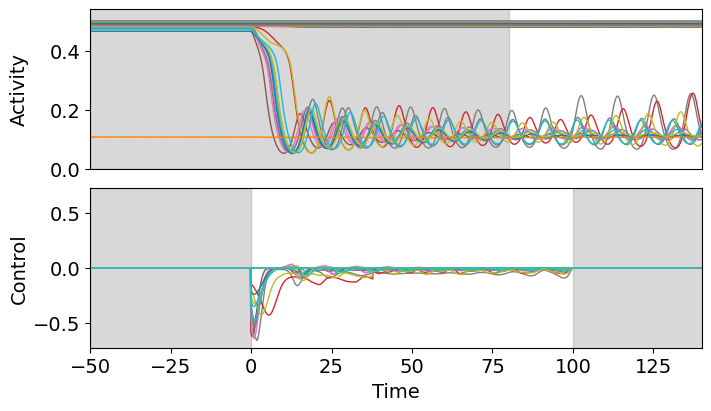

In [15]:
# plot results
ci = 0
costind = 1

offset = 50

model = WCModel(Cmat = ds.Cmat, Dmat = ds.Dmat)
model.params['duration'] = duration + offset
model.params['K_gl'] = 1.0
        
model.params['exc_ext_baseline'] = 2.68
model.params['inh_ext_baseline'] = 1.54

model.params["exc_init"] = data["init"][ci][:,0,:]
model.params["inh_init"] = data["init"][ci][:,1,:]

model.params.exc_ext = np.zeros((N, int((duration+offset)/dt) )) 
model.params.exc_ext[:,int(offset/dt-1):] = data["control_e"][costind][ci][:,0,:].copy()
model.run()

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(2, 1, figsize=(7, 4), layout="constrained")
time = np.arange(-offset, duration, dt)

print(time.shape)

for n in range(N):
    ax[0].plot(time, model.exc[n,:], linewidth=1)
    ax[1].plot(time, model.params.exc_ext[n,:], linewidth=1)

ax[0].fill_between([-offset, cost_interval[0]*dt], 0, 1, color="gray", alpha=0.3)
ax[1].fill_between([control_interval[1]*dt, duration+1], -10, 10, color="gray", alpha=0.3)
ax[1].fill_between([-offset, 0], -10, 10, color="gray", alpha=0.3)

ax[0].set_xlim(-offset, duration)
ax[1].set_xlim(-offset, duration)

ax[0].set_ylim(0, 0.54)
ylim = np.amax(np.abs(data["control_e"][costind][ci][:,0,:]))*1.1
ax[1].set_ylim(-ylim, ylim)

ax[0].set_xticks([])
ax[1].set_xlabel("Time")

#if ci == 0:
#    if costind == 0:
#        ax[0].set_title("Cross-correlation cost")
#    elif costind == 1:
#        ax[0].set_title("Variance cost")

ax[0].set_ylabel("Activity")
ax[1].set_ylabel("Control")

ax[0].yaxis.set_label_coords(-0.1, 0.5)
ax[1].yaxis.set_label_coords(-0.1, 0.5)

plt.savefig("ss_" + str(costind) + str(ci) + ".pdf")

In [ ]:
# read data from file
with open(os.path.join(datadir, 'data_osc_stationary_wb.pickle'), 'rb') as handle:
    data_read = pickle.load(handle)

data = data_read